In [7]:
# DEPENDENCIES
# Math functionality
import math 
# Numpy for working with arrays
import numpy as np
# Plotting functionality
import matplotlib.pyplot as plt

# 2D Stress Analysis and Mohr's Circle

## Determine the stresses on a particular plane

In [8]:
# Enter in the known values for sigma x, sigma y, tau xy
sig_x = -32.5
sig_y = 8.2
tau_xy = -10

# Enter in the angle of interest
theta_d = -35

# Convert the angle of the element into radians so it can be input into calculations
theta = theta_d*math.pi/180

# Calculate the stresses on an element oriented at theta degrees
sig_x1 = 0.5*(sig_x + sig_y) + 0.5*(sig_x - sig_y)*np.cos(2*theta) + tau_xy*np.sin(2*theta)
sig_y1 = 0.5*(sig_x + sig_y) - 0.5*(sig_x - sig_y)*np.cos(2*theta) - tau_xy*np.sin(2*theta)
tau_x1y1 = -0.5*(sig_x - sig_y)*np.sin(2*theta) + tau_xy*np.cos(2*theta)

# Print the results
print('Stresses on planes orientated at {one} degrees to the xy axes'.format(one = theta_d))
print('- sig_x1 = {one} N/mm^2'.format(one = round(sig_x1, 1)))
print('- sig_y1 = {one} N/mm^2'.format(one = round(sig_y1, 1)))
print('- tau_x1 = {one} N/mm^2'.format(one = round(tau_x1y1, 1)), end = '\n\n')

Stresses on planes orientated at -35 degrees to the xy axes
- sig_x1 = -9.7 N/mm^2
- sig_y1 = -14.6 N/mm^2
- tau_x1 = -22.5 N/mm^2



## Determine the principal stresses and the angle of the principal planes

In [15]:
# Calculate the angle of the principal planes
theta_1 = 0.5*math.atan((2*tau_xy)/(sig_x - sig_y))
theta_2 = theta_1 + (math.pi/2)
theta_1d = theta_1*(180/math.pi)
theta_2d = theta_2*(180/math.pi)

# Determine the principal stresses
sig_1 = 0.5*(sig_x + sig_y) + 0.5*(sig_x - sig_y)*np.cos(2*theta_1) + tau_xy*np.sin(2*theta_1)
sig_2 = 0.5*(sig_x + sig_y) + 0.5*(sig_x - sig_y)*np.cos(2*theta_2) + tau_xy*np.sin(2*theta_2)

# Check which principal stress is the major principle stress (sigma 1) and which is the minor principle stress (sigma 2)
print('Planes of the major and minor principle stresses')
if(sig_1 > sig_2):
    print('- The major principle stress is {one} N/mm^2 and occurs on a plane orientated at {two} degrees'.format(one = round(sig_1, 1), two = round(theta_1d, 1)))
    print('- The minor principle stress is {one} N/mm^2 and occurs on a plane orientated at {two} degrees'.format(one = round(sig_2, 1), two = round(theta_2d, 1)), end = '\n\n')
else:
    print('- The major principle stress is {one} N/mm^2 and occurs on a plane orientated at {two} degrees'.format(one = round(sig_2, 1), two = round(theta_2d, 1)))
    print('- The minor principle stress is {one} N/mm^2 and occurs on a plane orientated at {two} degrees'.format(one = round(sig_1, 1), two = round(theta_1d, 1)), end = '\n\n')

Planes of the major and minor principle stresses
- The major principle stress is 10.5 N/mm^2 and occurs on a plane orientated at 103.1 degrees
- The minor principle stress is -34.8 N/mm^2 and occurs on a plane orientated at 13.1 degrees



## Determine the planes of maximum positive and negative shear stress

In [17]:
# The plane of maximum positive shear stress is sigma 1 - 45 degrees. Find out which principle stress is sigma 1
if(sig_1 > sig_2):
    theta_s1 = theta_1d - 45
else:
    theta_s1 = theta_2d - 45

# The plane of maximum negative shear stress is orientated at 90 degrees from the plane of maximum positive shear stress
theta_s2 = theta_s1 + 90

# Print out the planes of maximum positive and negative shear stresses
print('Planes of maximum positive and negative shear stress')
print('- The maximum positive shear stress occurs on a plane orientated at {one} degrees'.format(one = round(theta_s1, 1)))
print('- The maximum negative shear stress occurs on a plane orientated at {one} degrees'.format(one = round(theta_s2, 1)), end = '\n\n')

# Maximum shear stress
tau_max = abs(0.5 * (sig_1 - sig_2))
sig_s = 0.5 * (sig_x + sig_y)

# Print the value of the maximum shear stress and the normal stress at this plane
print('Maximum shear stress and its associated normal stress values')
print('- The maximum shear stress has a magnitude of {one} N/mm^2'.format(one = round(tau_max, 1)))
print('- The normal stress on the maximum shear stress planes is {one} N/mm^2'.format(one = round(sig_s, 1)), end = '\n\n')

Planes of maximum positive and negative shear stress
- The maximum positive shear stress occurs on a plane orientated at 58.1 degrees
- The maximum negative shear stress occurs on a plane orientated at 148.1 degrees

Maximum shear stress and its associated normal stress values
- The maximum shear stress has a magnitude of 22.7 N/mm^2
- The normal stress on the maximum shear stress planes is -12.2 N/mm^2



## Plot the normal and shear stresses on all planes for this point in the material

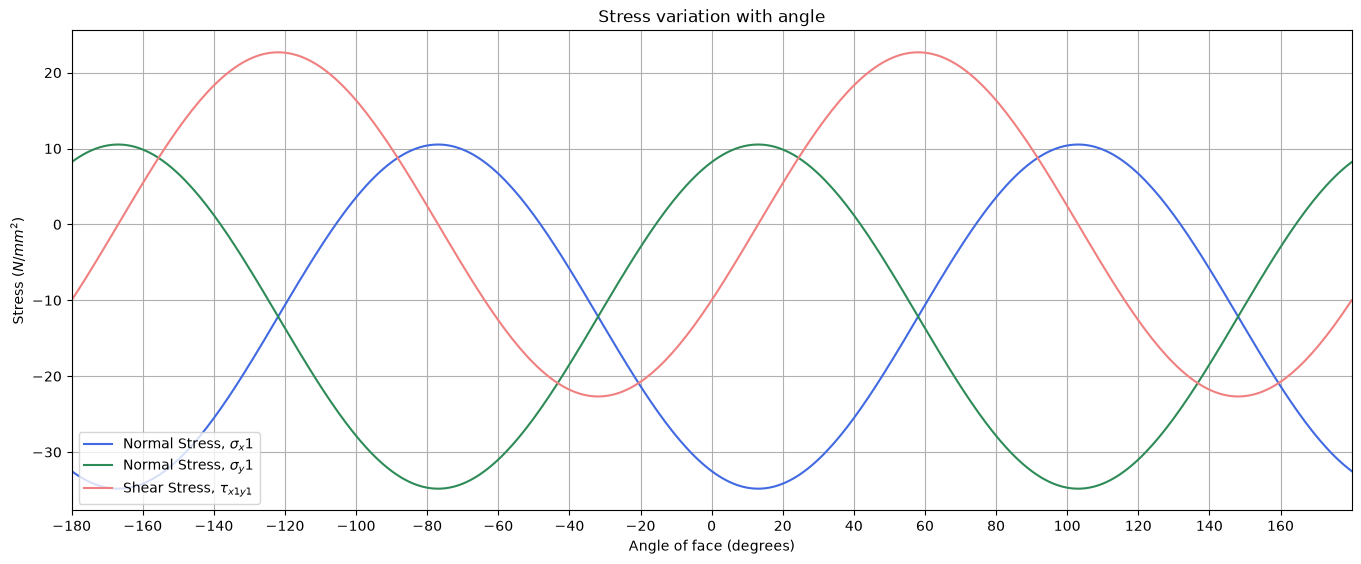

In [18]:
# Create a range of angles in degrees for the x-axis of the plot
theta = np.arange(-180, 181) 

# Convert to radians
theta_rad = math.pi/180*theta

# Determine the values of sig_x1, sig_y1 and tau_x1y1 for element orientations between -180 degrees and 180 degrees
Sig_x1 = 0.5*(sig_x + sig_y) + 0.5*(sig_x - sig_y)*np.cos(2*theta_rad) + tau_xy*np.sin(2*theta_rad)
Sig_y1 = 0.5*(sig_x + sig_y) - 0.5*(sig_x - sig_y)*np.cos(2*theta_rad) - tau_xy*np.sin(2*theta_rad)
Tau_x1y1 = -0.5*(sig_x - sig_y)*np.sin(2*theta_rad) + tau_xy*np.cos(2*theta_rad)

# Define a figure
fig = plt.figure()

# Add a set of axes to the figure
axes = fig.add_axes([0.1,0.1,2,1])

# Plot the transformation equations
axes.plot(theta, Sig_x1, 'royalblue', label='Normal Stress, $\sigma_x1$')
axes.plot(theta, Sig_y1, 'seagreen', label='Normal Stress, $\sigma_y1$')
axes.plot(theta, Tau_x1y1, 'lightcoral', label='Shear Stress, $\\tau_{x1y1}$')

# Set an x label
axes.set_xlabel('Angle of face (degrees)')

# Set a y label
axes.set_ylabel('Stress $(N/mm^2)$')

# Set a title
axes.set_title('Stress variation with angle')

# Add x axis limits to -180, 180
axes.set_xlim([-180,180])

# Add tick marks at every 20 degrees
axes.set_xticks(np.arange(-180,180,20))

# Add a legend
axes.legend(loc='lower left')

# Add a grid to the plot
plt.grid()

# Show the plot
plt.show()

## Drawing Mohr's Circle

<function matplotlib.pyplot.show(close=None, block=None)>

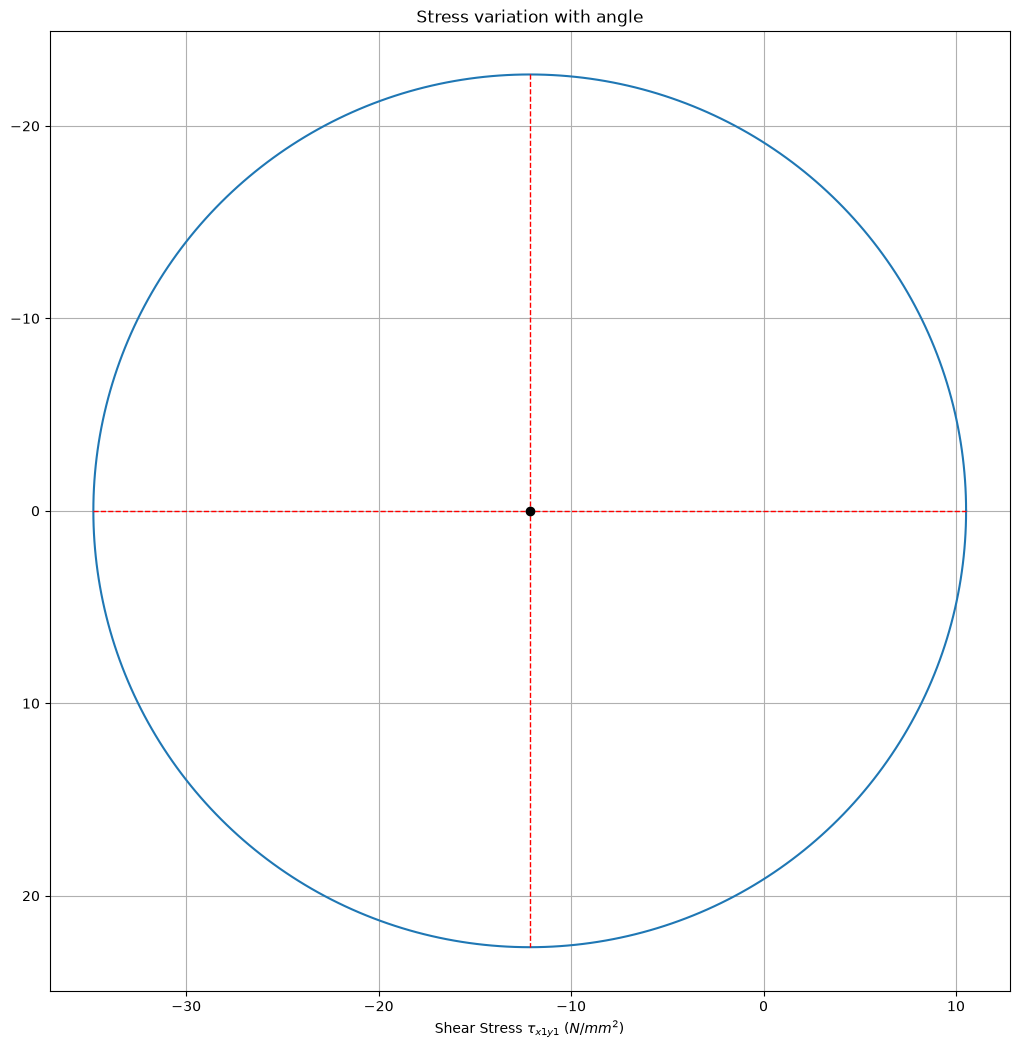

In [19]:
# Construct the circle
# Calculate Sigma average
sig_avg = 0.5*(sig_x + sig_y)

# Calculate the radius of the circle
R = math.sqrt(((sig_x - sig_y)/2)**2 + (tau_xy)**2)

# Get all the angles of a circle
theta = np.arange(0, 361)

# Convert to radians
theta_rad = math.pi/180*theta

# Get all the x points on the circle
sig_x1 = sig_avg + R*np.cos(theta_rad)

# Get all the y points on the circle
tau_x1y1 = R*np.sin(theta_rad)

# Plot the circle
fig = plt.figure()

# Add axes
axes = fig.add_axes([0.1,0.1,2,2])

# Make sure x and y axes have the same aspect ratio so it looks like a circle
fig.gca().set_aspect('equal', adjustable = 'box')

# Plot the circle
axes.plot(sig_x1, tau_x1y1)

# Make the vertical axis positive pointing down
axes.invert_yaxis()

# Add axis labels and title
axes.set_xlabel('Normal Stress $\sigma_{x1}$ $(N/mm^2)$')
axes.set_xlabel('Shear Stress $\\tau_{x1y1}$ $(N/mm^2)$')
axes.set_title('Stress variation with angle')

# Add horizontal diameter in the centre of the circle
axes.plot([sig_avg - R, sig_avg + R], [0, 0], '--', color = 'red', linewidth = 1)

# Add vertical diameter in the centre of the circle
axes.plot([sig_avg, sig_avg], [-R, R], '--', color = 'red', linewidth = 1)

# Add dot in centre of circle
axes.plot([sig_avg], [0], 'o', color = 'black')

# Add gridlines to plot
axes.grid()

# Optionally save the result as a png
# plt.savefig('Mohr.png', dpi=100, bbox_inches = 'tight')

# Show the plot
plt.show